In [ ]:
!pip install scanpy anndata

In [ ]:
!pip install muon

  Using cached muon-0.1.7-py3-none-any.whl.metadata (7.2 kB)
  Using cached mudata-0.3.8-py3-none-any.whl.metadata (10 kB)
Using cached muon-0.1.7-py3-none-any.whl (293 kB)
Using cached mudata-0.3.8-py3-none-any.whl (43 kB)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from huggingface_hub import notebook_login
notebook_login()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
!git clone https://github.com/minwoosun/UCE.git

Cloning into 'UCE'...
remote: Enumerating objects: 151, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 151 (delta 66), reused 47 (delta 47), pack-reused 71 (from 1)
Receiving objects: 100% (151/151), 67.75 KiB | 2.05 MiB/s, done.
Resolving deltas: 100% (80/80), done.


In [ ]:
%cd UCE

/content/UCE


In [ ]:
! pip install -r requirements.txt

In [ ]:
import scanpy as sc
import anndata
path = "/content/drive/MyDrive/GP_datasets/CBMC/cbmc_rna_filtered.h5ad"
adata = sc.read_h5ad(path)
adata

AnnData object with n_obs × n_vars = 8617 × 19626
    obs: 'size_factors'
    var: 'n_counts', 'feature_name', 'hvg', 'hvg_score', 'gene_symbols'
    uns: '_from_cache', 'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'normalization_id', 'var_names_all'
    obsm: 'X_svd', 'mode2'
    layers: 'counts', 'normalized'

In [ ]:
adata.var.head()

,n_counts,feature_name,hvg,hvg_score,gene_symbols
HUMAN_A1BG,7.0,HUMAN_A1BG,False,0.46490699135472746,A1BG
HUMAN_A1BG-AS1,22.0,HUMAN_A1BG-AS1,False,0.40879803825589356,A1BG-AS1
HUMAN_A1CF,3.0,HUMAN_A1CF,False,0.4587354678010472,A1CF
HUMAN_A2M,16.0,HUMAN_A2M,False,0.43117187790241857,A2M
HUMAN_A2M-AS1,170.0,HUMAN_A2M-AS1,False,0.2899705160233493,A2M-AS1


In [ ]:
# swap the var id to have the values from gene_symbols
adata.var["gene_symbols"] = adata.var["gene_symbols"].astype(str)

# set gene symbols as new index
adata.var_names = adata.var["gene_symbols"]

# optional but recommended: remove duplicates
adata = adata[:, ~adata.var_names.duplicated()].copy()

In [ ]:
import numpy as np

# convert to string safely
adata.var_names = adata.var_names.astype(str)

# remove invalid gene names
valid_mask = (
    (adata.var_names != "0") &
    (adata.var_names != "nan") &
    (adata.var_names != "") &
    (~adata.var_names.isna())
)

adata = adata[:, valid_mask].copy()

In [ ]:
print([x for x in adata.var_names[:50] if x in ["0", "nan", "", None]])

[]


In [ ]:
print(sum(adata.var_names == "0"))

0


In [ ]:
import anndata as ad

ad.settings.allow_write_nullable_strings = True

In [ ]:
# convert ALL string columns in obs to plain python strings
for col in adata.obs.columns:
    if adata.obs[col].dtype.name in ["string", "StringArray", "ArrowStringArray"]:
        adata.obs[col] = adata.obs[col].astype(str)

# ensure var_names are plain strings too
adata.var_names = adata.var_names.astype(str)

In [ ]:
def sanitize_anndata(adata):
    adata.obs = adata.obs.astype(str)
    adata.var = adata.var.astype(str)
    adata.var_names = adata.var_names.astype(str)
    return adata

adata = sanitize_anndata(adata)

In [ ]:
import numpy as np

# convert ALL obs columns to plain python strings
adata.obs = adata.obs.astype(str)

# convert var to safe strings too
adata.var = adata.var.astype(str)

# ensure index is clean strings
adata.obs_names = adata.obs_names.astype(str)
adata.var_names = adata.var_names.astype(str)

In [ ]:
for col in adata.obs.columns:
    adata.obs[col] = adata.obs[col].astype(str)

In [ ]:
adata.obs.index = adata.obs.index.astype(str)
adata.var.index = adata.var.index.astype(str)

In [ ]:
print(adata.shape)

(8617, 18924)


In [ ]:
adata.write_h5ad("/content/temp1.h5ad")

In [ ]:
adata.write_h5ad("/content/drive/MyDrive/GP_datasets/cbmc_rna_filtered_gene_symbols.h5ad")

### run model on loaded data

In [ ]:
! python eval_single_anndata.py --adata_path "/content/temp1.h5ad" --dir "./"  --model_loc "minwoosun/uce-100m"


Download Complete!
Proccessing temp1
5367.0
temp1 (8616, 11803)
Wrote Shapes Dict
11803
Max Code: 613
config.json: 100% 115/115 [00:00<00:00, 495kB/s]
pytorch_model.bin: 100% 3.40G/3.40G [01:12<00:00, 46.7MB/s]
Loaded model:
minwoosun/uce-100m
100% 345/345 [11:00<00:00,  1.91s/it]
*****Wrote Anndata to:*****
./temp1_uce_adata.h5ad


In [ ]:
import scanpy as sc
import anndata
emb_path = "/content/UCE/temp1_uce_adata.h5ad"
adata_rna = sc.read_h5ad(emb_path)
adata_rna

AnnData object with n_obs × n_vars = 8616 × 11803
    obs: 'size_factors', 'n_genes'
    var: 'n_counts', 'feature_name', 'hvg', 'hvg_score', 'gene_symbols', 'n_cells'
    uns: '_from_cache', 'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'normalization_id', 'var_names_all'
    obsm: 'X_svd', 'X_uce', 'mode2'
    layers: 'counts', 'normalized'

In [ ]:
adata_rna.write_h5ad("/content/drive/MyDrive/GP_datasets/CBMCs_rna_embeddings_uce.h5ad")

In [ ]:
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import os
import subprocess
import pandas as pd
import numpy as np
import logging
import torch
import scanpy as sc
import anndata
logging.getLogger().setLevel(logging.ERROR)

warnings.filterwarnings("ignore")

In [ ]:
adata_rna = sc.read_h5ad("/content/drive/MyDrive/GP_datasets/CBMCs_rna_embeddings_uce.h5ad")
adata_rna

AnnData object with n_obs × n_vars = 8616 × 11803
    obs: 'size_factors', 'n_genes'
    var: 'n_counts', 'feature_name', 'hvg', 'hvg_score', 'gene_symbols', 'n_cells'
    uns: '_from_cache', 'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'normalization_id', 'var_names_all'
    obsm: 'X_svd', 'X_uce', 'mode2'
    layers: 'counts', 'normalized'

# Data exploring

In [ ]:
adata_rna.obs.head()

,size_factors,n_genes
AAACCTGAGAAACCGC,1841.0,770
AAACCTGAGCAGGTCA,1839.0,719
AAACCTGAGGCATGGT,1649.0,683
AAACCTGAGTGGTCCC,1752.0,773
AAACCTGCAAGGTTCT,4003.0,1338


In [ ]:
adata_rna.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 7257303 stored elements and shape (8616, 11803)>

In [ ]:
adata_rna.obsm["X_uce"]

array([[ 0.03200002,  0.02211932, -0.05222484, ...,  0.01791975,
         0.02827276, -0.02706028],
       [ 0.02388529,  0.02502747, -0.00424695, ...,  0.02843009,
         0.02134047,  0.03208587],
       [ 0.03730026, -0.00936477, -0.03997434, ...,  0.01377472,
         0.0252022 , -0.03911714],
       ...,
       [-0.01611959,  0.03783178, -0.01094006, ...,  0.04718528,
        -0.00645839,  0.02917087],
       [ 0.01791574,  0.00337801, -0.03017798, ...,  0.00653335,
        -0.01031589, -0.01572657],
       [ 0.00382683,  0.01285738,  0.0102712 , ...,  0.02667456,
         0.01568652,  0.03373552]], dtype=float32)

In [ ]:
adata_adt=sc.read_h5ad("/content/drive/MyDrive/GP_datasets/CBMC/cbmc_adt.h5ad")
adata_adt

AnnData object with n_obs × n_vars = 8617 × 13
    var: 'feature_name', 'hvg', 'hvg_score'
    uns: 'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'normalization_id'
    obsm: 'X_svd'
    layers: 'counts', 'normalized'

In [ ]:
print(adata_adt.X)

None


In [ ]:
common = adata_rna.obs_names.intersection(adata_adt.obs_names)

In [ ]:
adata_rna = adata_rna[common].copy()
adata_adt = adata_adt[common].copy()

In [ ]:
print(adata_rna.shape)
print(adata_adt.shape)

(8616, 11803)
(8616, 13)


In [ ]:
X = adata_rna.obsm["X_uce"]
# hvg_mask = adata_rna.var["hvg"].values
# X = X[:, hvg_mask]
y = adata_adt.layers["normalized"]

In [ ]:
X.shape

(8616, 1280)

In [ ]:
y.shape

(8616, 13)

In [ ]:
X = X.toarray() if hasattr(X, "toarray") else X
y = y.toarray() if hasattr(y, "toarray") else y

# Model

In [ ]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = LinearRegression()
mse_scores = []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

# per-protein MSE
mse_per_protein = ((y_test - y_pred) ** 2).mean(axis=0)

# overall mean
avg_mse = mse_per_protein.mean()

print("Avg MSE:", avg_mse)
print("Per-protein MSE:", mse_per_protein)
print("Per-protein MSE shape:", mse_per_protein.shape)

Avg MSE: 0.114133134
Per-protein MSE: [0.09144828 0.08996614 0.44985306 0.11142667 0.13017157 0.0756941
 0.07888468 0.09337491 0.06795921 0.07323692 0.08282836 0.07532819
 0.06355876]
Per-protein MSE shape: (13,)


In [ ]:
rmse_per_protein = np.sqrt(mse_per_protein)
avg_rmse = rmse_per_protein.mean()

print("Avg RMSE:", avg_rmse)
print("Per-protein RMSE:", rmse_per_protein)
print("Per-protein RMSE shape:", rmse_per_protein.shape)

Avg RMSE: 0.32114628
Per-protein RMSE: [0.30240417 0.29994357 0.67071086 0.33380634 0.36079296 0.2751256
 0.28086418 0.30557308 0.26068988 0.2706232  0.28779915 0.2744598
 0.25210863]
Per-protein RMSE shape: (13,)


In [ ]:
from scipy.stats import pearsonr

pearson_per_protein = []

for i in range(y_test.shape[1]):
    if np.std(y_test[:, i]) > 0 and np.std(y_pred[:, i]) > 0:
        corr, _ = pearsonr(y_test[:, i], y_pred[:, i])
    else:
        corr = np.nan
    pearson_per_protein.append(corr)

pearson_per_protein = np.array(pearson_per_protein)
mean_pearson = np.nanmean(pearson_per_protein)

print("Avg Pearson correlation:", mean_pearson)
print("Per-protein Pearson correlation:", pearson_per_protein)
print("Per-protein Pearson shape:", pearson_per_protein.shape)

Avg Pearson correlation: 0.7436276
Per-protein Pearson correlation: [0.9371228  0.912034   0.74072945 0.8757151  0.72046983 0.81013036
 0.4592508  0.9231252  0.8059552  0.8687536  0.61983687 0.54279596
 0.45123973]
Per-protein Pearson shape: (13,)


In [ ]:
import numpy as np

corrs = []
for i in range(y.shape[1]):
    corr = np.corrcoef(y_test[:, i], y_pred[:, i])[0,1]
    corrs.append(corr)

print("Avg correlation:", np.mean(corrs))

Avg correlation: 0.7436276110130305


In [ ]:
from scipy.stats import spearmanr

spearman_per_protein = []

for i in range(y_test.shape[1]):
    if np.std(y_test[:, i]) > 0 and np.std(y_pred[:, i]) > 0:
        corr, _ = spearmanr(y_test[:, i], y_pred[:, i])
    else:
        corr = np.nan
    spearman_per_protein.append(corr)

spearman_per_protein = np.array(spearman_per_protein)
mean_spearman = np.nanmean(spearman_per_protein)

print("Mean Spearman correlation:", mean_spearman)
print("Per-protein Spearman correlation:", spearman_per_protein)
print("Per-protein Spearman shape:", spearman_per_protein.shape)

Mean Spearman correlation: 0.6123641289233915
Per-protein Spearman correlation: [0.81459854 0.84829942 0.46626094 0.85991474 0.59309513 0.5361001
 0.32486361 0.80515975 0.76212434 0.57562019 0.51371208 0.43877601
 0.42220881]
Per-protein Spearman shape: (13,)


In [ ]:
valid_idx = np.where(~np.isnan(pearson_per_protein))[0]
valid_scores = pearson_per_protein[valid_idx]

sorted_idx = valid_idx[np.argsort(valid_scores)]

worst_idx = sorted_idx[0]
median_idx = sorted_idx[len(sorted_idx)//2]
best_idx = sorted_idx[-1]

selected_idx = [worst_idx, median_idx, best_idx]
labels = ["Worst", "Median", "Best"]

protein_names = np.array(adata_adt.var_names)

print("\nSelected proteins:")
for label, idx in zip(labels, selected_idx):
    print(
        f"{label}: {protein_names[idx]} "
        f"(Pearson = {pearson_per_protein[idx]:.4f})"
    )


Selected proteins:
Worst: CCR7 (Pearson = 0.4512)
Median: CD14 (Pearson = 0.8060)
Best: CD3 (Pearson = 0.9371)


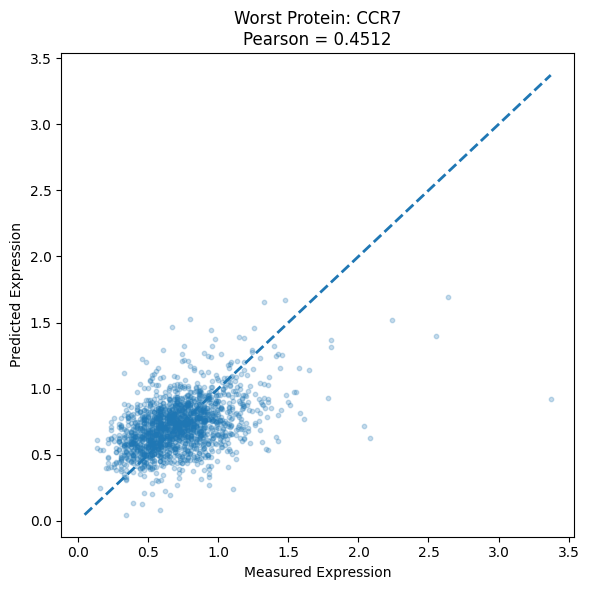

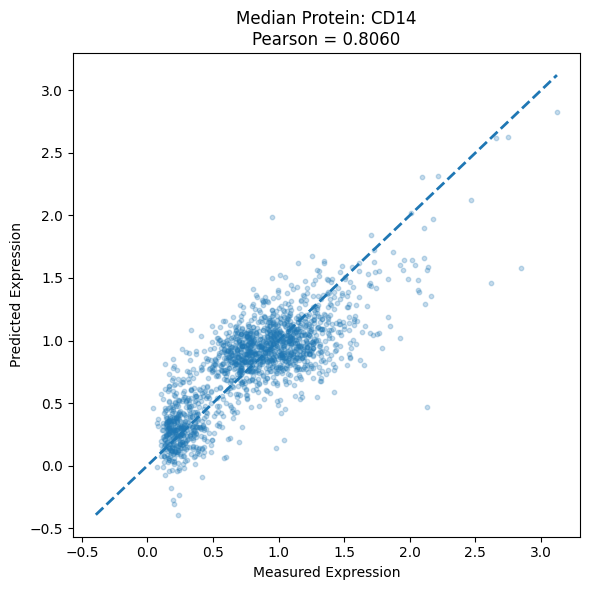

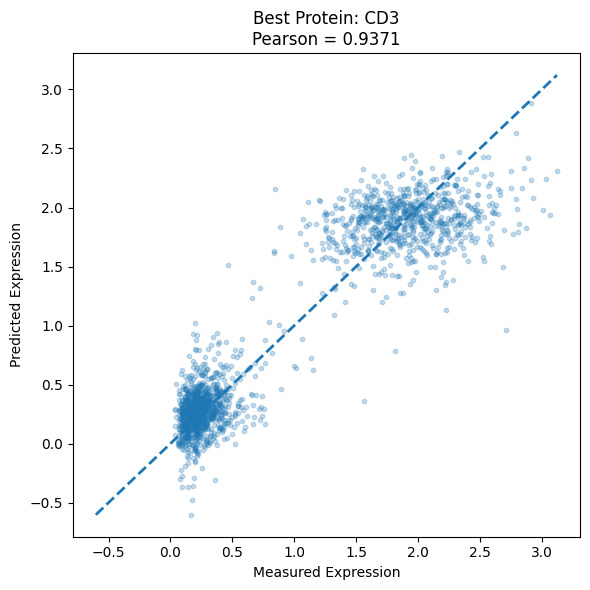

In [ ]:
import matplotlib.pyplot as plt

for label, idx in zip(labels, selected_idx):

    x = y_test[:, idx]
    yhat = y_pred[:, idx]

    plt.figure(figsize=(6,6))

    plt.scatter(
        x,
        yhat,
        s=10,
        alpha=0.25
    )

    mn = min(x.min(), yhat.min())
    mx = max(x.max(), yhat.max())

    plt.plot([mn, mx], [mn, mx], "--", linewidth=2)

    plt.xlabel("Measured Expression")
    plt.ylabel("Predicted Expression")

    plt.title(
        f"{label} Protein: {protein_names[idx]}\n"
        f"Pearson = {pearson_per_protein[idx]:.4f}"
    )

    plt.tight_layout()
    plt.show()

In [ ]:
from pathlib import Path
import numpy as np

save_path = Path("/content/drive/MyDrive/GP_datasets/results")
save_path.mkdir(parents=True, exist_ok=True)

model_name = "UCE"  # change per notebook

np.savez(
    save_path / f"{model_name}_CBMCs_protein_results.npz", # change dataset name

    # raw outputs
    y_test=y_test,
    y_pred=y_pred,

    # metadata
    protein_names=protein_names,

    # metrics
    pearson_per_protein=pearson_per_protein,

    # selected indices (diagnostic)
    worst_idx=worst_idx,
    median_idx=median_idx,
    best_idx=best_idx,

    selected_idx=np.array(selected_idx),

    mean_pearson=np.nanmean(pearson_per_protein),
)

print(f"Saved results for {model_name} at:", save_path)

Saved results for UCE at: /content/drive/MyDrive/GP_datasets/results
